### Aplicação ANN for Regression

Vamos fazer a aplicação de uma ANN para regressão linear, considerando o método de perda MSE (já que temos predições contínuas de valores numéticos)

In [2]:
# import libraries
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

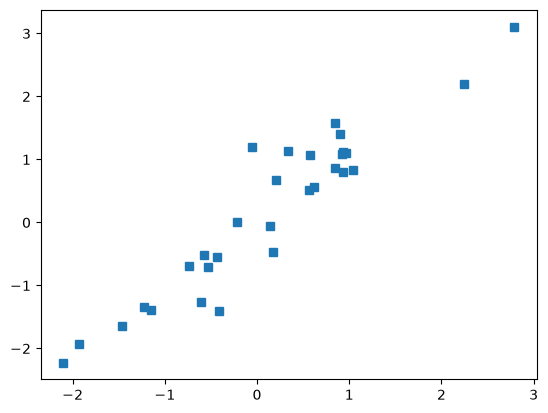

In [ ]:
# create data

N = 30
x = torch.randn(N,1) # similar to Pandas, generate random numbers
y = x + torch.randn(N,1)/2

# plot the generated data
plt.plot(x,y,'s')
plt.show()

In [ ]:
# build modelo ANN to regression simple

ANNreg = nn.Sequential(
    nn.Linear(1,1), # input layer
    nn.ReLU(),      # activation function
    nn.Linear(1,1)  # output layer
)

ANNreg

Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1, out_features=1, bias=True)
)

In [8]:
# learning rate
learning_rate = 0.05

# loss function
lossfun = nn.MSELoss()

# optimizer (the flavor of gradient descent to implement)
optimizer = torch.optim.SGD(ANNreg.parameters(),lr=learning_rate)

In [10]:
# train the model
numepochs = 500
losses = torch.zeros(numepochs)

## Train the model!
for epochi in range(numepochs):

    # foward pass
    yHat = ANNreg(x)
    
    # compute loss (MRE)
    loss = lossfun(yHat, y)
    losses[epochi] = loss

    #backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

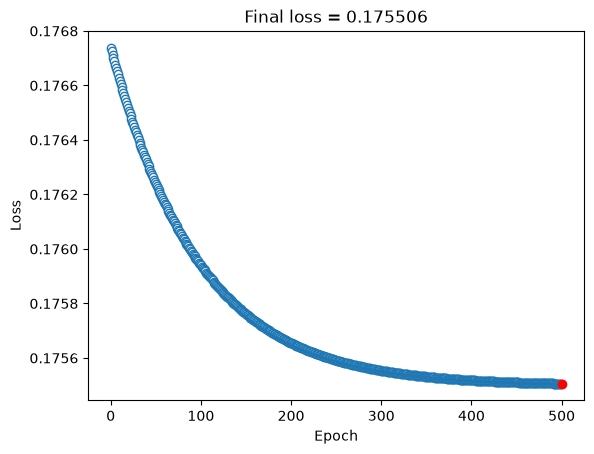

In [13]:
# show the losses

# manually compute losses
# final forward pass
predictions = ANNreg(x)

# final loss (MSE)
testloss = (predictions-y).pow(2).mean()

plt.plot(losses.detach(),'o', markerfacecolor='w', linewidth=.1)
plt.plot(numepochs,testloss.detach(),'ro')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Final loss = %g' %testloss.item())
plt.show()